In [30]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/fast/pmayilvahanan/post_training/dapo/verl/notebooks')
from utils import collate_experiment_results
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [31]:
base_results_dir = '/fast/pmayilvahanan/post_training/verl_checkpoints/self_distillation_neurips/Qwen'

In [32]:
results = collate_experiment_results(base_results_dir)

In [34]:
results.columns

Index(['exp_name', 'training_type', 'step', 'model', 'lr', 'training_data',
       'epochs', 'total_training_steps', 'train_batch_size',
       'micro_batch_size', 'val/HuggingFaceH4/aime_2024/pass@1/mean@8',
       'val/HuggingFaceH4/aime_2024/pass@8/mean',
       'val/math-ai/aime25/pass@1/mean@8', 'val/math-ai/aime25/pass@8/mean',
       'val/math-ai/amc23/pass@1/mean@8', 'val/math-ai/amc23/pass@8/mean',
       'val/math-ai/gpqa/pass@1/mean@8', 'val/math-ai/gpqa/pass@8/mean',
       'val/math-ai/minervamath/pass@1/mean@8',
       'val/math-ai/minervamath/pass@8/mean',
       'val/math-ai/olympiadbench/pass@1/mean@8',
       'val/math-ai/olympiadbench/pass@8/mean',
       'val/simplescaling/openaimath/pass@1/mean@8',
       'val/simplescaling/openaimath/pass@8/mean'],
      dtype='object')

In [37]:
columns_pass1 = ['val/math-ai/aime25/pass@1/mean@8',
                 'val/math-ai/amc23/pass@1/mean@8',
                 'val/math-ai/minervamath/pass@1/mean@8',
                 'val/math-ai/olympiadbench/pass@1/mean@8',
                 'val/HuggingFaceH4/aime_2024/pass@1/mean@8',
                 'val/math-ai/gpqa/pass@1/mean@8',
                 ]
columns_pass8 = ['val/math-ai/aime25/pass@8/mean',
                 'val/math-ai/amc23/pass@8/mean',
                 'val/math-ai/minervamath/pass@8/mean',
                 'val/math-ai/olympiadbench/pass@8/mean',
                 'val/HuggingFaceH4/aime_2024/pass@8/mean',
                 'val/math-ai/gpqa/pass@8/mean',
                 ]

# Create OOD metrics as the mean of the columns
results['OOD/pass@1/mean@8'] = results[columns_pass1].mean(axis=1)
results['OOD/pass@8/mean'] = results[columns_pass8].mean(axis=1)


In [38]:
results_rl = results[results['training_type'] == 'RL']
results_sft = results[results['training_type'] == 'SFT']

## Analyzing RL results

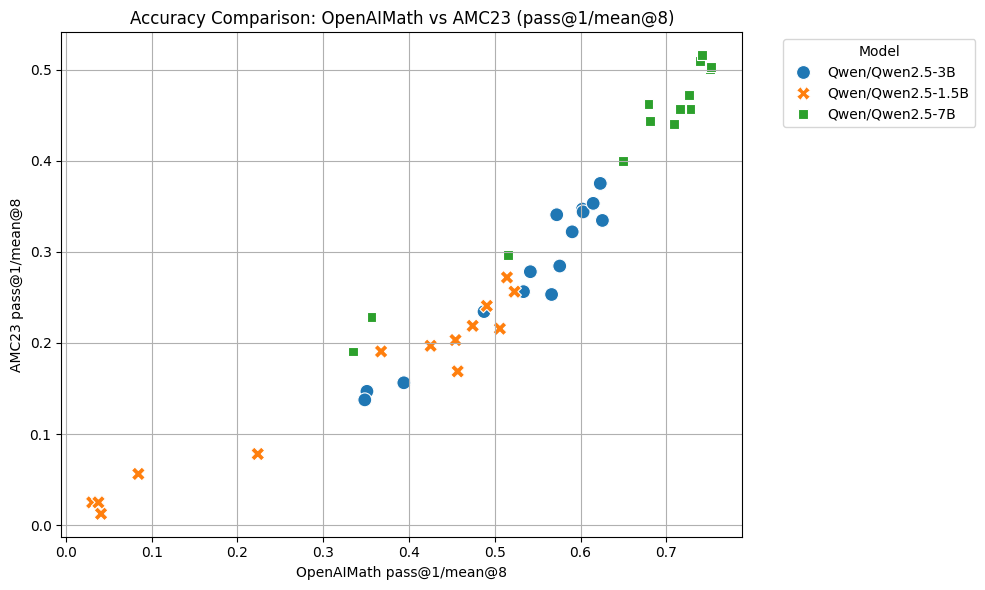

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=results_rl,
    x='val/simplescaling/openaimath/pass@1/mean@8',
    y='val/math-ai/amc23/pass@1/mean@8',
    hue='model',  # Different colors for models
    style='model', # Different markers for models
    s=100         # Marker size
)
plt.title('Accuracy Comparison: OpenAIMath vs AMC23 (pass@1/mean@8)')
plt.xlabel('OpenAIMath pass@1/mean@8')
plt.ylabel('AMC23 pass@1/mean@8')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

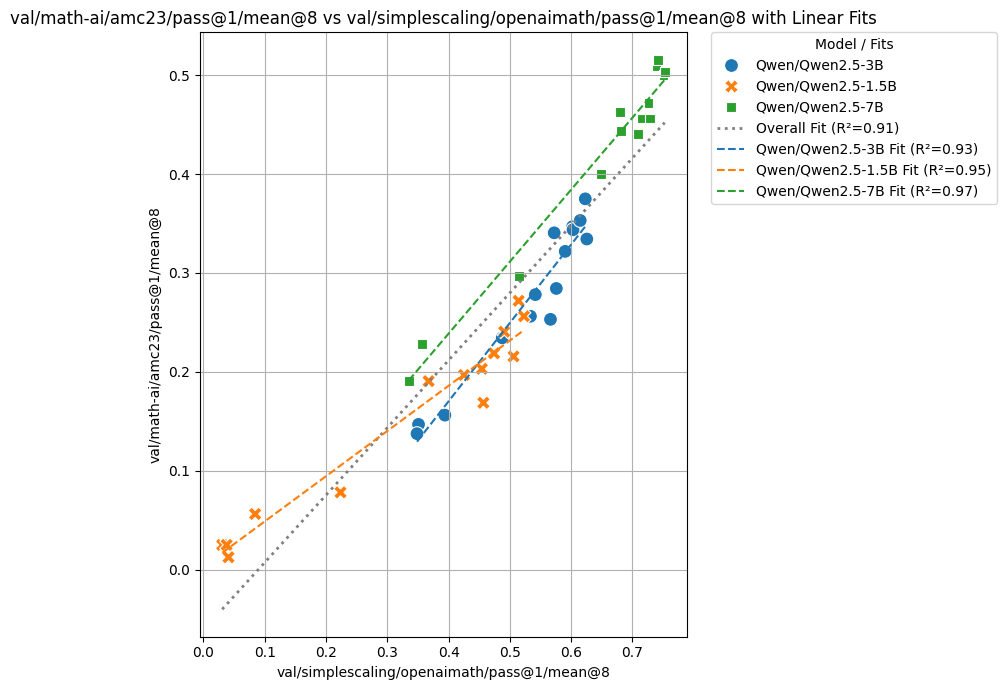

In [21]:
x_metric = 'val/simplescaling/openaimath/pass@1/mean@8'
y_metric = 'val/math-ai/amc23/pass@1/mean@8'
model_column = 'model'

plt.figure(figsize=(12, 7)) # Adjusted figure size for a better legend layout

# 1. Scatter plot
ax = sns.scatterplot(
    data=results_rl,
    x=x_metric,
    y=y_metric,
    hue=model_column,
    style=model_column,
    s=100
)

# Prepare data for fitting (ensure numeric and no NaNs for fitting)
# Convert to float and drop NaNs specifically for the metrics being plotted
x_data_all_plotting = results_rl[x_metric].astype(float)
y_data_all_plotting = results_rl[y_metric].astype(float)
valid_indices_all = x_data_all_plotting.notna() & y_data_all_plotting.notna()

x_data_all_fit = x_data_all_plotting[valid_indices_all]
y_data_all_fit = y_data_all_plotting[valid_indices_all]

# 2. Overall fit
if len(x_data_all_fit) > 1:
    m_all, b_all = np.polyfit(x_data_all_fit, y_data_all_fit, 1)
    
    # Calculate R-squared for the overall fit
    correlation_matrix_all = np.corrcoef(x_data_all_fit, y_data_all_fit)
    r_all = correlation_matrix_all[0, 1]
    r_squared_all = r_all**2
    
    # Create a range for plotting the line smoothly
    x_fit_range_all = np.array([x_data_all_fit.min(), x_data_all_fit.max()])
    plt.plot(x_fit_range_all, m_all * x_fit_range_all + b_all, color='grey', linestyle=':', linewidth=2, label=f'Overall Fit (R²={r_squared_all:.2f})')

# 3. Individual model fits
models = results_rl[model_column].unique()
# Get the palette used by seaborn for hue to match colors
# Note: This relies on the order of models being the same as how seaborn processes them.
# If colors don't match, you might need to manually map model_name to colors.
palette = sns.color_palette(n_colors=len(models))

for i, model_name in enumerate(models):
    model_data = results_rl[results_rl[model_column] == model_name]
    
    x_data_model_plotting = model_data[x_metric].astype(float)
    y_data_model_plotting = model_data[y_metric].astype(float)
    valid_indices_model = x_data_model_plotting.notna() & y_data_model_plotting.notna()

    x_data_model_fit = x_data_model_plotting[valid_indices_model]
    y_data_model_fit = y_data_model_plotting[valid_indices_model]

    if len(x_data_model_fit) > 1:
        m, b = np.polyfit(x_data_model_fit, y_data_model_fit, 1)
        
        # Calculate R-squared for the model fit
        correlation_matrix_model = np.corrcoef(x_data_model_fit, y_data_model_fit)
        r_model = correlation_matrix_model[0, 1]
        r_squared_model = r_model**2
        
        line_color = palette[i % len(palette)] # Cycle through palette colors
        
        x_fit_range_model = np.array([x_data_model_fit.min(), x_data_model_fit.max()])
        # The scatter plot already created legend entries for models based on 'hue'.
        # We add the R-squared to a new label for the line.
        # To avoid duplicate model names in legend, we can make line labels more specific.
        plt.plot(x_fit_range_model, m * x_fit_range_model + b, linestyle='--', linewidth=1.5, label=f'{model_name} Fit (R²={r_squared_model:.2f})', color=line_color)

plt.title(f'{y_metric} vs {x_metric} with Linear Fits')
plt.xlabel(x_metric)
plt.ylabel(y_metric)
# Adjust legend to be outside the plot for clarity
plt.legend(title='Model / Fits', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True)
# Adjust layout to make space for the legend outside the plot area
plt.tight_layout(rect=[0, 0, 0.75, 1]) # rect=[left, bottom, right, top]
plt.show()

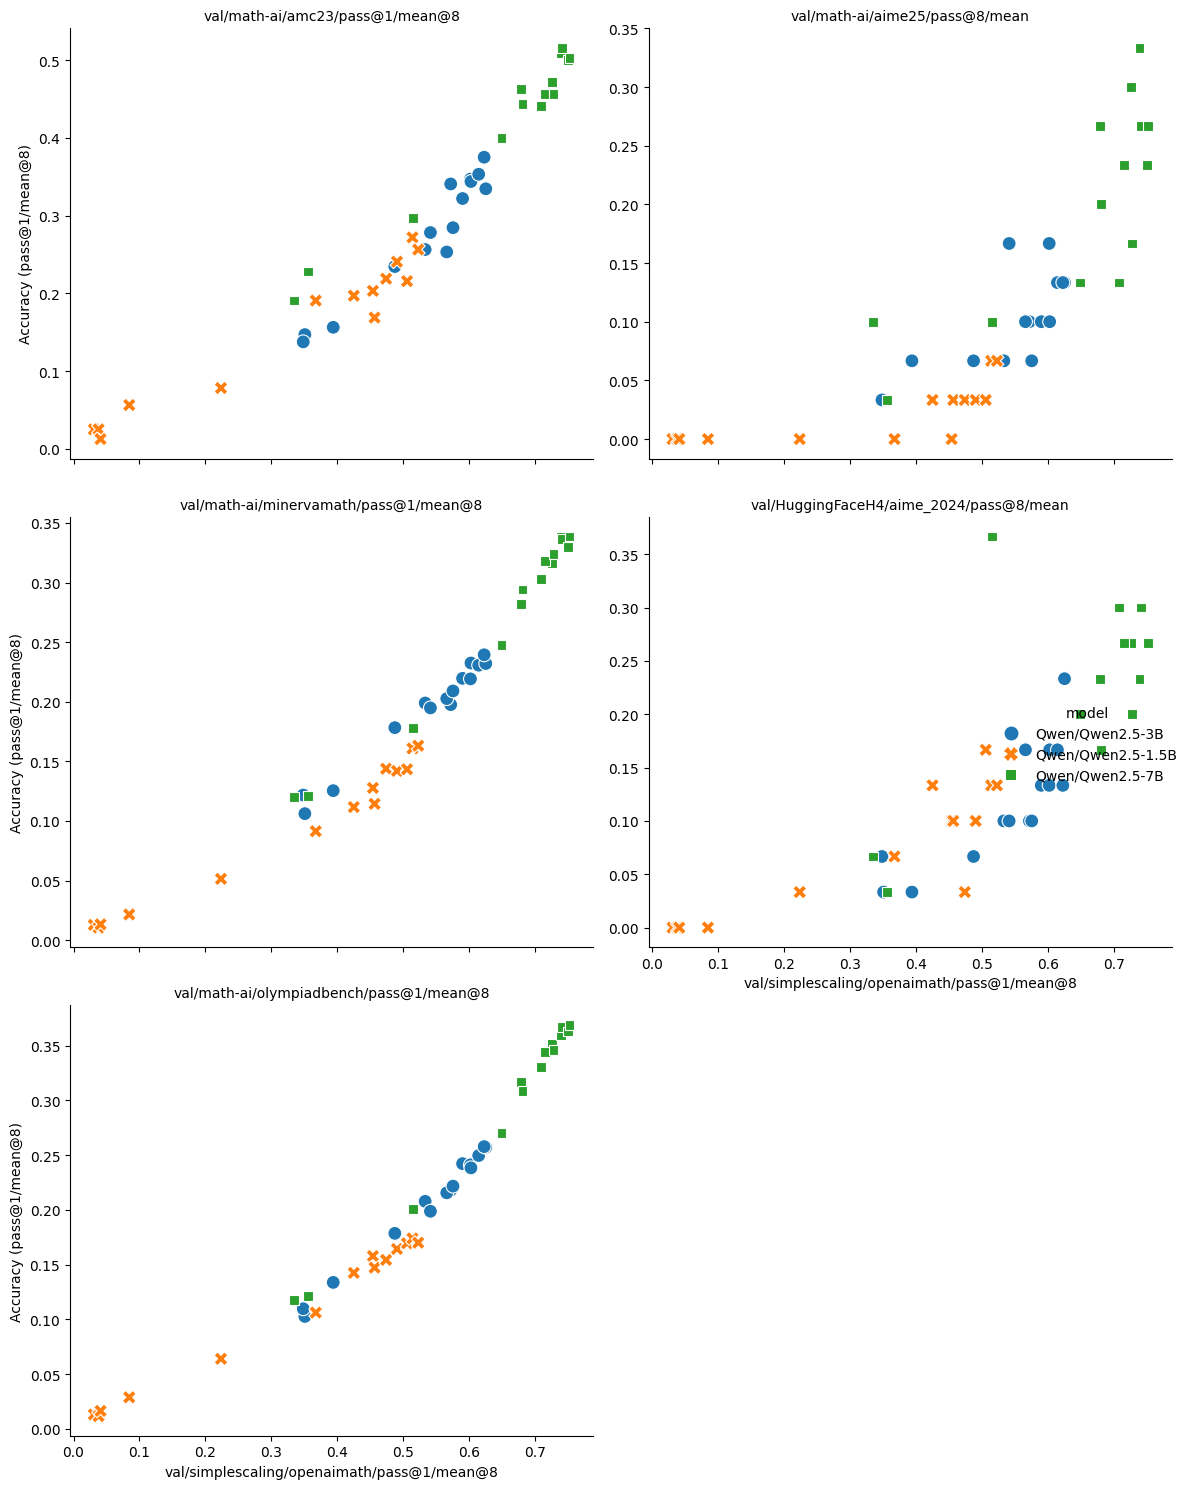

In [18]:
# Define your x metric and the list of y metrics
x_metric = 'val/simplescaling/openaimath/pass@1/mean@8'
y_metrics_list = [
    'val/math-ai/amc23/pass@1/mean@8',
    'val/math-ai/aime25/pass@8/mean',
    'val/math-ai/minervamath/pass@1/mean@8',
    'val/HuggingFaceH4/aime_2024/pass@8/mean',
    'val/math-ai/olympiadbench/pass@1/mean@8',
]
model_column = 'model' # or whatever your model identifier column is

# Melt the DataFrame to long format for easier plotting with Seaborn
id_vars_for_melt = [model_column, x_metric, 'exp_name', 'step'] # Add other identifiers if needed
# Ensure all y_metrics are actually in the dataframe
valid_y_metrics = [col for col in y_metrics_list if col in results_rl.columns]
if not valid_y_metrics:
    print(f"None of the specified y_metrics are in the DataFrame. Available columns: {results_rl.columns.tolist()}")
else:
    df_melted = results_rl.melt(
        id_vars=id_vars_for_melt,
        value_vars=valid_y_metrics,
        var_name='Y_Metric_Type',
        value_name='Y_Metric_Value'
    )

    # Create the plot
    g = sns.relplot(
        data=df_melted,
        x=x_metric,
        y='Y_Metric_Value',
        hue=model_column,
        style=model_column,
        col='Y_Metric_Type', # Creates a separate column for each Y metric
        kind='scatter',
        s=100,
        col_wrap=2,        # Wrap columns if you have many Y metrics
        facet_kws={'sharey': False, 'sharex': True} # Adjust sharing of axes as needed
    )

    g.set_titles("{col_name}") # Set titles for each subplot
    g.set_xlabels(f"{x_metric}")
    g.set_ylabels("Accuracy (pass@1/mean@8)")
    plt.tight_layout()
    plt.show()

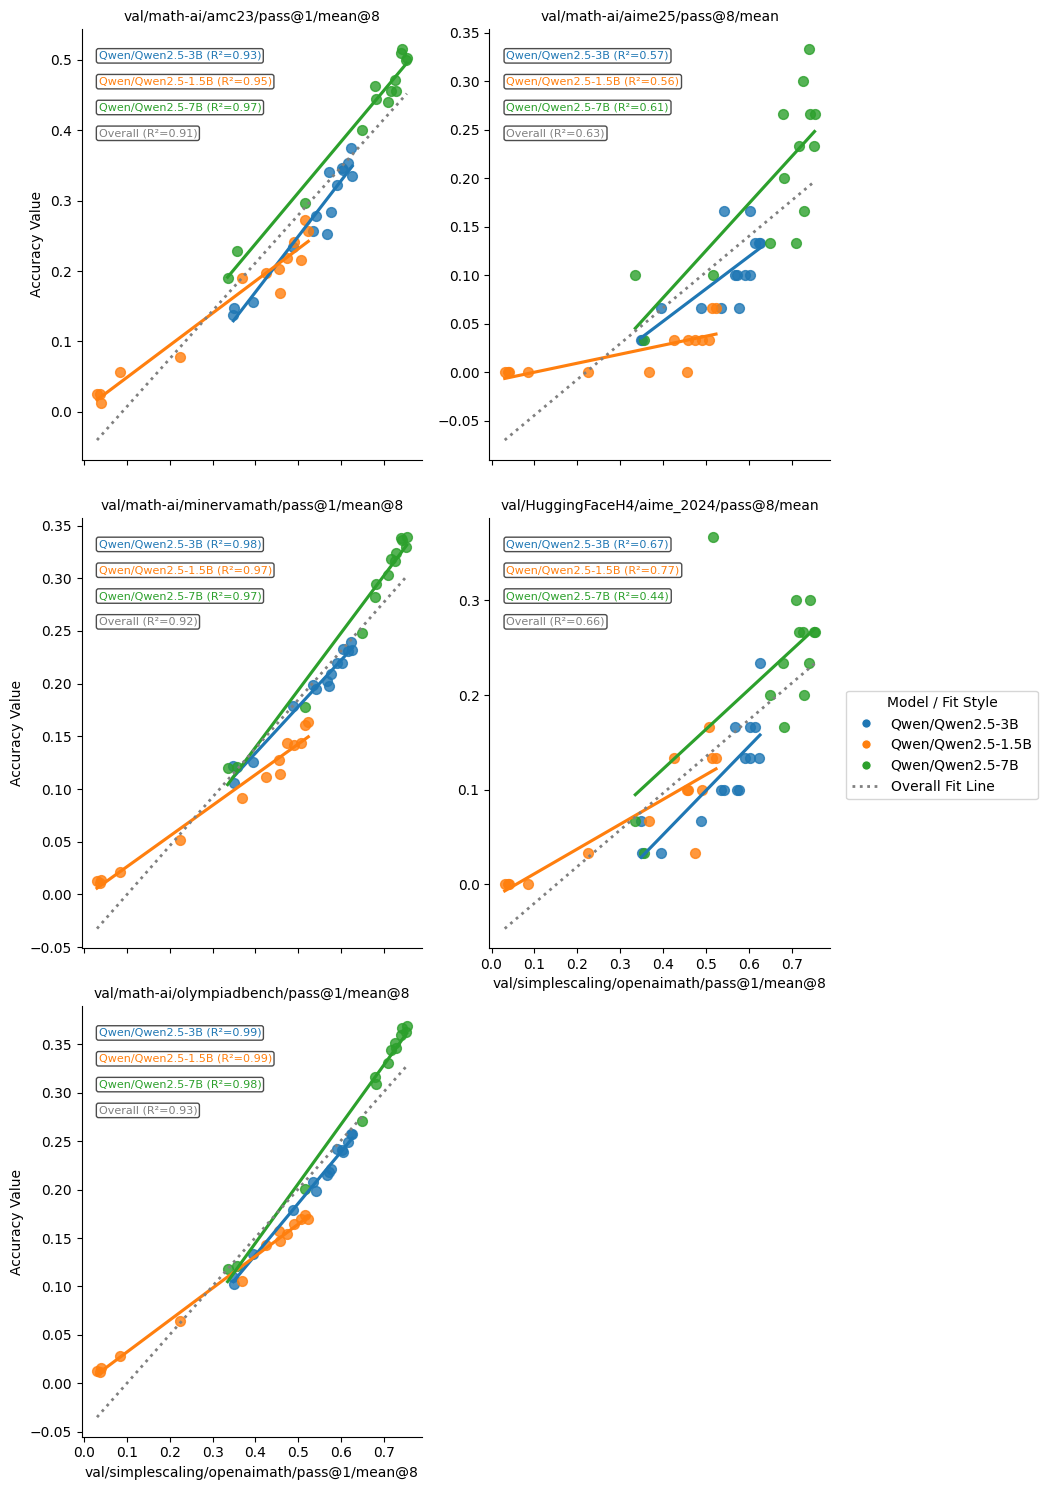

In [19]:
# Melt the DataFrame (ensure 'id_vars_for_melt' includes all necessary identifiers)
id_vars_for_melt = [model_column, x_metric, 'exp_name', 'step']
valid_y_metrics = [col for col in y_metrics_list if col in results_rl.columns]

if not valid_y_metrics:
    print(f"None of the specified y_metrics are in the DataFrame. Available columns: {results_rl.columns.tolist()}")
else:
    df_melted = results_rl.melt(
        id_vars=id_vars_for_melt,
        value_vars=valid_y_metrics,
        var_name='Y_Metric_Type',
        value_name='Y_Metric_Value'
    )

    # Create the faceted plot with lmplot for individual model fits
    g = sns.lmplot(
        data=df_melted,
        x=x_metric,
        y='Y_Metric_Value',
        hue=model_column,
        col='Y_Metric_Type',
        col_wrap=2, # Adjust as needed
        facet_kws={'sharey': False, 'sharex': True},
        ci=None,    # No confidence interval for cleaner plot
        scatter_kws={'s': 50},
        legend=False # Will handle legend/annotations manually
    )

    # Add R-squared annotations and overall fit line to each facet
    for i, ax_col_name in enumerate(g.col_names): # g.col_names gives the Y_Metric_Type for each column of facets
        # Handle cases where col_wrap might create more axes than there are Y_Metric_Types
        # This loop assumes g.axes is a 1D array if col_wrap is used, or 2D if not.
        # We iterate using g.col_names to map to the correct data.
        
        axes_in_col = g.axes_dict.get(ax_col_name, None) # For newer seaborn versions, axes_dict is useful
        if axes_in_col is None and len(g.axes.shape) == 1 and i < len(g.axes): # Fallback for older or 1D axes array
             axes_in_col = g.axes[i]
        elif axes_in_col is None:
            continue


        ax = axes_in_col # Current axis for the facet

        current_y_metric_type = ax_col_name
        
        # Filter original DataFrame for overall fit on this facet
        facet_data_orig_x = results_rl[x_metric].dropna().astype(float)
        facet_data_orig_y = results_rl[current_y_metric_type].dropna().astype(float)
        
        valid_indices_facet_all = facet_data_orig_x.index.intersection(facet_data_orig_y.index)
        x_all_facet = facet_data_orig_x[valid_indices_facet_all]
        y_all_facet = facet_data_orig_y[valid_indices_facet_all]

        if len(x_all_facet) > 1:
            m_overall_facet, b_overall_facet = np.polyfit(x_all_facet, y_all_facet, 1)
            r_overall_facet = np.corrcoef(x_all_facet, y_all_facet)[0, 1]
            r2_overall_facet = r_overall_facet**2
            
            x_fit_range_overall = np.array([x_all_facet.min(), x_all_facet.max()])
            ax.plot(x_fit_range_overall, m_overall_facet * x_fit_range_overall + b_overall_facet, 
                    color='grey', linestyle=':', linewidth=2, label=f'Overall (R²={r2_overall_facet:.2f})')

        # Annotate R-squared for individual models (lmplot plots the lines)
        models_on_facet = df_melted[df_melted['Y_Metric_Type'] == current_y_metric_type][model_column].unique()
        text_y_pos = 0.95 # Starting Y position for text annotation on the axes
        palette_lm = sns.color_palette(n_colors=len(models_on_facet)) # Palette for model colors

        for j, model_name in enumerate(models_on_facet):
            # Filter original DataFrame for this model and Y_Metric_Type
            model_specific_data = results_rl[results_rl[model_column] == model_name]
            model_x_facet = model_specific_data[x_metric].dropna().astype(float)
            model_y_facet = model_specific_data[current_y_metric_type].dropna().astype(float)

            valid_indices_model_facet = model_x_facet.index.intersection(model_y_facet.index)
            x_model_valid_facet = model_x_facet[valid_indices_model_facet]
            y_model_valid_facet = model_y_facet[valid_indices_model_facet]

            if len(x_model_valid_facet) > 1:
                r_model_facet = np.corrcoef(x_model_valid_facet, y_model_valid_facet)[0, 1]
                r2_model_facet = r_model_facet**2
                # lmplot hue colors are usually from sns.color_palette()
                model_color = palette_lm[j % len(palette_lm)] 
                ax.text(0.05, text_y_pos, f'{model_name} (R²={r2_model_facet:.2f})', 
                        transform=ax.transAxes, fontsize=8, color=model_color, 
                        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
                text_y_pos -= 0.06 # Adjust for next text line
        
        # Annotate Overall R-squared on the plot as well
        if len(x_all_facet) > 1:
             ax.text(0.05, text_y_pos, f'Overall (R²={r2_overall_facet:.2f})', 
                     transform=ax.transAxes, fontsize=8, color='grey', verticalalignment='top',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    g.set_titles("{col_name}")
    g.set_xlabels(f"{x_metric}")
    g.set_ylabels("Accuracy Value")
    
    # Add a single combined legend for model hues (markers) and the overall fit line style
    handles = []
    labels = []
    
    # Get model hue handles from lmplot (it creates them internally)
    # We can create proxy artists for the legend
    unique_models_for_legend = df_melted[model_column].unique()
    palette_for_legend = sns.color_palette(n_colors=len(unique_models_for_legend))
    for k, model_name_leg in enumerate(unique_models_for_legend):
        handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                                  markerfacecolor=palette_for_legend[k % len(palette_for_legend)], 
                                  markersize=7, label=model_name_leg))
        labels.append(model_name_leg)

    # Add overall fit line style
    if any(len(results_rl[x_metric].dropna()) > 1 and len(results_rl[ym].dropna()) > 1 for ym in valid_y_metrics): # Check if any overall fit was made
        handles.append(plt.Line2D([0], [0], color='grey', linestyle=':', linewidth=2))
        labels.append('Overall Fit Line')

    if handles:
        g.fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.05, 0.5), title="Model / Fit Style")

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout for legend
    plt.show()

## Analyze SFT results

In [28]:
results_sft_7b = results_sft[results_sft['model'] == 'Qwen/Qwen2.5-7B']
results_sft_3b = results_sft[results_sft['model'] == 'Qwen/Qwen2.5-3B']

In [29]:
results_sft_3b

,exp_name,training_type,step,model,lr,training_data,epochs,total_training_steps,train_batch_size,micro_batch_size,...,val/math-ai/amc23/pass@1/mean@8,val/math-ai/amc23/pass@8/mean,val/math-ai/gpqa/pass@1/mean@8,val/math-ai/gpqa/pass@8/mean,val/math-ai/minervamath/pass@1/mean@8,val/math-ai/minervamath/pass@8/mean,val/math-ai/olympiadbench/pass@1/mean@8,val/math-ai/olympiadbench/pass@8/mean,val/simplescaling/openaimath/pass@1/mean@8,val/simplescaling/openaimath/pass@8/mean
21,qwen_2.5_3b_base_sft_data_Qwen2.5-3B_openai_ma...,SFT,NaN,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,qwen_2.5_3b_base_sft_data_Qwen2.5-14B_openai_m...,SFT,6.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.143750,0.550,0.017045,0.085859,0.109835,0.327206,0.111111,0.362963,0.34200,0.742
23,qwen_2.5_3b_base_sft_data_Qwen2.5-14B_openai_m...,SFT,12.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.143750,0.500,0.015783,0.075758,0.106618,0.341912,0.100741,0.333333,0.32700,0.698
24,qwen_2.5_3b_base_sft_data_Qwen2.5-14B_openai_m...,SFT,18.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.109375,0.425,0.011995,0.070707,0.084559,0.297794,0.073889,0.271111,0.28825,0.670
25,qwen_2.5_3b_base_sft_data_Qwen2.5-14B_openai_m...,SFT,6.0,Qwen/Qwen2.5-3B,0.000010,train_common_indices_3_7_14,5,90,64,256,...,0.096875,0.500,0.011364,0.070707,0.081342,0.297794,0.069630,0.290370,0.28650,0.654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,42.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.118750,0.375,0.012626,0.060606,0.099265,0.334559,0.088704,0.311111,0.30450,0.696
133,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,48.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.128125,0.450,0.015783,0.090909,0.093750,0.294118,0.087963,0.302222,0.30725,0.688
134,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,54.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.096875,0.375,0.018939,0.101010,0.091452,0.341912,0.084259,0.309630,0.29625,0.680
135,qwen_2.5_3b_base_sft_data_Qwen2.5-7B_openai_ma...,SFT,60.0,Qwen/Qwen2.5-3B,0.000001,train_common_indices_3_7_14,5,90,64,256,...,0.140625,0.625,0.015152,0.065657,0.097886,0.312500,0.091296,0.333333,0.30275,0.700
